# Evaluate TFLite CNN Models on Entire Dataset
This notebook evaluates the `cnn_Future_Hypotension.tflite`, `cnn_Future_Hypoxia.tflite`, and `cnn_Future_Tachycardia.tflite` models on the full dataset, calculating and plotting essential metrics like accuracy, precision, recall, confusion matrix, ROC curve, etc.


In [1]:
import os
import glob
import json
import numpy as np
import pandas as pd
import tensorflow as tf
from sklearn.metrics import confusion_matrix, roc_curve, auc, precision_recall_curve, accuracy_score, precision_score, recall_score, f1_score, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

# --- Config ---
WINDOW_SIZE = 600
STRIDE = 5
BATCH_SIZE = 64

# Resolving paths
base_dir = os.path.dirname(os.getcwd())
if os.path.exists(os.path.join(os.getcwd(), "patient_labeled_data")):
    input_dir = os.path.join(os.getcwd(), "patient_labeled_data")
elif os.path.exists(os.path.join(os.getcwd(), "..", "patient_labeled_data")):
    input_dir = os.path.join(os.getcwd(), "..", "patient_labeled_data")
else:
    input_dir = "../patient_labeled_data"

csv_files = sorted(glob.glob(os.path.join(input_dir, "patient_*_1hz.csv")))

base_features = [
    "Solar8000/HR", "Solar8000/ART_SBP", "Solar8000/ART_DBP", "Solar8000/ART_MBP",
    "Solar8000/PLETH_SPO2", "Solar8000/RR_CO2", "Solar8000/ETCO2", "Primus/FIO2", "Solar8000/BT"
]
engineered_features = [
    "Feature_Pulse_Pressure", "Feature_Shock_Index", "Feature_Modified_Shock_Index",
    "Feature_Rate_Pressure_Product", "Feature_HR_Mean_60s", "Feature_HR_Std_60s",
    "Feature_HR_Delta_60s", "Feature_MBP_Mean_60s", "Feature_MBP_Std_60s", "Feature_MBP_Delta_60s"
]
features = base_features + engineered_features

print(f"Total CSV Files for Evaluation: {len(csv_files)}")


I0000 00:00:1787227552.693679    4232 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE3 SSE4.1 SSE4.2 AVX AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


Total CSV Files for Evaluation: 3107


In [2]:
class WindowDataGenerator:
    def __init__(self, file_list, target_col, features, batch_size=64, window_size=600, stride=5):
        self.batch_size = batch_size
        self.window_size = window_size
        self.stride = stride
        self.X_data = []
        self.y_data = []
        self.window_indices = []
        
        print(f"Pre-loading raw CSVs into memory for {target_col}...")
        for file_idx, file in enumerate(tqdm(file_list, desc=f"Loading data for {target_col}")):
            try:
                df = pd.read_csv(file)
                avail_features = [c for c in features if c in df.columns]
                if len(avail_features) < len(features) or target_col not in df.columns:
                    continue
                
                df_sub = df[avail_features + [target_col]].ffill().bfill().fillna(0)
                arr = df_sub[avail_features].values.astype(np.float32)
                y_vals = df_sub[target_col].values.astype(np.float32)
                
                self.X_data.append(arr)
                self.y_data.append(y_vals)
                
                # Pre-calculate valid window start indices for this patient
                for i in range(0, len(arr) - window_size, stride):
                    if not np.isnan(y_vals[i + window_size - 1]):
                        self.window_indices.append((file_idx, i))
                        
            except Exception as e:
                continue
                
        self.indices = np.arange(len(self.window_indices))
            
    def __len__(self):
        return int(np.ceil(len(self.window_indices) / self.batch_size))
        
    def __getitem__(self, idx):
        batch_inds = self.indices[idx * self.batch_size : (idx + 1) * self.batch_size]
        X_batch = np.empty((len(batch_inds), self.window_size, len(features)), dtype=np.float32)
        y_batch = np.empty((len(batch_inds),), dtype=np.float32)
        
        for i, b_idx in enumerate(batch_inds):
            file_idx, start = self.window_indices[b_idx]
            X_batch[i] = self.X_data[file_idx][start : start + self.window_size]
            y_batch[i] = self.y_data[file_idx][start + self.window_size - 1]
            
        return X_batch, y_batch


In [3]:
def predict_tflite(tflite_path, data_gen):
    interpreter = tf.lite.Interpreter(model_path=tflite_path)
    interpreter.allocate_tensors()
    input_details = interpreter.get_input_details()
    output_details = interpreter.get_output_details()
    
    y_pred = []
    y_true = []
    
    for i in tqdm(range(len(data_gen)), desc=f"Evaluating {tflite_path}"):
        X_batch, y_batch = data_gen.__getitem__(i)
        for j in range(len(X_batch)):
            input_data = np.expand_dims(X_batch[j], axis=0)
            interpreter.set_tensor(input_details[0]['index'], input_data)
            interpreter.invoke()
            output_data = interpreter.get_tensor(output_details[0]['index'])
            y_pred.append(output_data[0][0])
            y_true.append(y_batch[j])
            
    return np.array(y_true), np.array(y_pred)

def evaluate_model(y_true, y_pred_prob, target_name):
    y_pred = (y_pred_prob > 0.5).astype(int)
    
    print(f"\n--- Metrics for {target_name} ---")
    print("Accuracy:", accuracy_score(y_true, y_pred))
    print("Precision:", precision_score(y_true, y_pred, zero_division=0))
    print("Recall:", recall_score(y_true, y_pred, zero_division=0))
    print("F1 Score:", f1_score(y_true, y_pred, zero_division=0))
    print("\nClassification Report:\n", classification_report(y_true, y_pred, zero_division=0))
    
    # Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'Confusion Matrix: {target_name}')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.show()
    
    # ROC Curve
    fpr, tpr, _ = roc_curve(y_true, y_pred_prob)
    roc_auc = auc(fpr, tpr)
    plt.figure(figsize=(6,4))
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'Receiver Operating Characteristic: {target_name}')
    plt.legend(loc="lower right")
    plt.show()
    
    # Precision-Recall Curve
    precision, recall, _ = precision_recall_curve(y_true, y_pred_prob)
    plt.figure(figsize=(6,4))
    plt.plot(recall, precision, color='purple', lw=2)
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title(f'Precision-Recall Curve: {target_name}')
    plt.show()



 Evaluating model for: Future_Hypotension 
Pre-loading raw CSVs into memory for Future_Hypotension...


Loading data for Future_Hypotension: 100%|██████████| 3107/3107 [01:16<00:00, 40.44it/s]
/usr/lib/python3.14/site-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)
INFO: Created TensorFlow Lite XNNPACK delegate for CPU.
Evaluating cnn_future_hypotension_pure_float32.tflite: 100%|██████████| 117963/117963 [03:37<00:00, 543.06it/s]



--- Metrics for Future_Hypotension ---
Accuracy: 0.8224558657684624
Precision: 0.6448141884865695
Recall: 0.7252215476569547
F1 Score: 0.6826583152374125

Classification Report:
               precision    recall  f1-score   support

         0.0       0.90      0.86      0.88   5561635
         1.0       0.64      0.73      0.68   1987947

    accuracy                           0.82   7549582
   macro avg       0.77      0.79      0.78   7549582
weighted avg       0.83      0.82      0.83   7549582



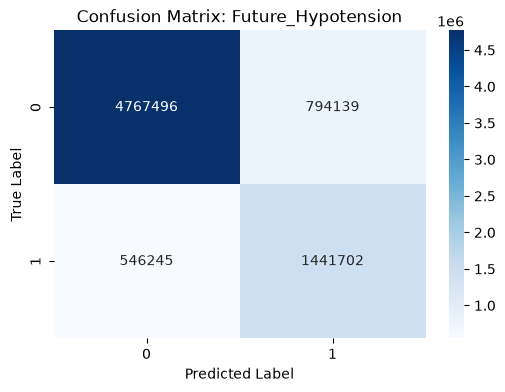

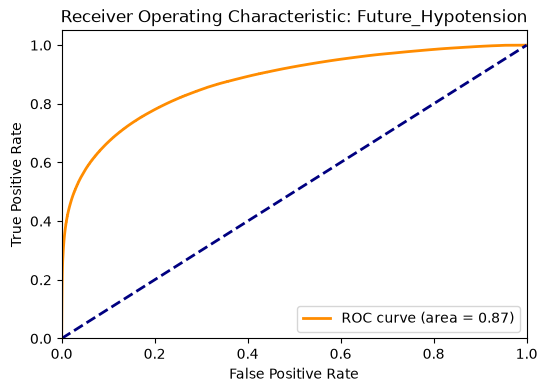

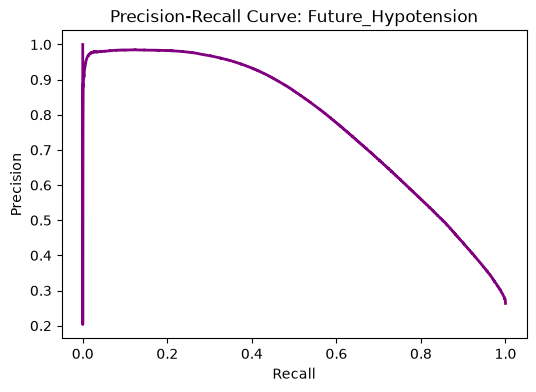


 Evaluating model for: Future_Hypoxia 
Pre-loading raw CSVs into memory for Future_Hypoxia...


Loading data for Future_Hypoxia:  36%|███▌      | 1117/3107 [00:25<00:43, 45.26it/s]

In [ ]:
targets = {
    "Future_Hypotension": "cnn_future_hypotension_pure_float32.tflite",
    "Future_Hypoxia": "cnn_Future_Hypoxia.tflite",
    "Future_Tachycardia": "cnn_Future_Tachycardia.tflite"
}

# Subsetting files if you want to avoid out-of-memory errors on large datasets
# For the entire dataset, we use all files. 
# Warning: Generating window data for hundreds of files can take significant memory!
eval_files = csv_files

for target, model_file in targets.items():
    if not os.path.exists(model_file):
        print(f"Model file {model_file} not found. Skipping...")
        continue
        
    print(f"\n{'='*60}\n Evaluating model for: {target} \n{'='*60}")
    
    data_gen = WindowDataGenerator(eval_files, target, features, BATCH_SIZE, WINDOW_SIZE, STRIDE)
    
    if len(data_gen) == 0:
         print(f"No valid data found for {target}. Skipping...")
         continue
         
    y_true, y_pred_prob = predict_tflite(model_file, data_gen)
    
    evaluate_model(y_true, y_pred_prob, target)
